# RQ4 — ISP-Level Performance & Market-Share Comparison (9 Countries, incl. Singapore)

Rebuilding step by step. Step 1: top-5 ISPs by test volume, broadband and cellular separate, per
country — same style as the existing per-country EDA chart (`outputs/ndt7/<country>/24_per_isp.png`),
capped at top 5 instead of top 15, built from the pre-aggregated
`data/exports/ndt7_isp_<country>_quarterly.csv` files (no parquet re-query), pooled across all
12 quarters (2023-Q1 to 2025-Q4) rather than one quarter at a time, and **merged by brand**
(`operator`) so a brand with multiple ASNs (e.g. Thailand's AIS = AS133481 + AS131445 + AS45430,
True = AS17552 + AS7470 + AS132618 + AS132061) shows as one bar, not one per ASN.

**Extra merge rule found while building this:** some ASNs have no `operator` label but their
`as_name` is an *exact* string match to the `as_name` of a different ASN that *does* carry an
operator label (e.g. Thailand AS132032's `as_name` is "Total Access Communication PLC." — the
exact same string as AS24378, which is labeled `operator="dtac"`). That's a safe inherit — exact
string identity, not a guess from a garbled/wrong name (unlike ip-api's `as_name` occasionally
being flat-out wrong, e.g. "Binariang Berhad" for what is actually Maxis) — so these inherit the
matching operator too. ASNs with no `operator` and no exact `as_name` match to a labeled brand
still stay separate, labeled `<as_name> (ASxxxxx)`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')
OUT = Path('../../outputs/ndt7/comparison')
OUT.mkdir(parents=True, exist_ok=True)

COUNTRIES = ['thailand', 'vietnam', 'philippines', 'indonesia',
             'cambodia', 'laos', 'malaysia', 'myanmar', 'singapore']
COUNTRY_LABEL = {c: c.title() for c in COUNTRIES}

frames = []
for c in COUNTRIES:
    d = pd.read_csv(EXPORTS / f'ndt7_isp_{c}_quarterly.csv', dtype={'asn': str})
    d['country'] = c
    frames.append(d)
raw = pd.concat(frames, ignore_index=True)
raw.shape

(35126, 18)

In [2]:
def wavg(s, w):
    s, w = np.asarray(s, dtype=float), np.asarray(w, dtype=float)
    return np.average(s, weights=w) if w.sum() > 0 else np.nan


# exact as_name match -> inherit that operator (safe: identical string, not a guess from a
# possibly-wrong/garbled as_name). Built per (country, network_type) so the same as_name string
# in a different country/segment doesn't cross-contaminate.
asname_to_operator = (
    raw[raw['operator'].notna()]
    .groupby(['country', 'network_type', 'as_name'])['operator']
    .agg(lambda s: s.mode().iat[0])
)

def effective_operator(row):
    if pd.notna(row['operator']):
        return row['operator']
    key = (row['country'], row['network_type'], row['as_name'])
    return asname_to_operator.get(key, np.nan)

raw['operator_eff'] = raw.apply(effective_operator, axis=1)
print('extra rows inherited via exact as_name match:',
      int((raw['operator'].isna() & raw['operator_eff'].notna()).sum()))


def brand_key(row):
    if pd.notna(row['operator_eff']):
        return row['operator_eff']
    if row['asn'] == '(unknown)':
        return '(unknown ASN)'
    name = str(row['as_name'])[:28] if pd.notna(row['as_name']) else f"AS{row['asn']}"
    return f"{name} (AS{row['asn']})"

raw['brand'] = raw.apply(brand_key, axis=1)


# pool all 12 quarters, merge ASNs of the same brand (operator) together.
# unlabeled ASNs stay separate -- each is its own brand key, never merged by guessing.
def rollup_brand(g):
    tt = g['total_tests']
    return pd.Series({
        'total_tests': tt.sum(),
        'avg_d_mbps':  wavg(g['avg_d_mbps'], tt),
        'n_asn':       g['asn'].nunique(),
    })

brand_all = (raw.groupby(['country', 'network_type', 'brand'], observed=True)
                .apply(rollup_brand, include_groups=False)
                .reset_index())
brand_all['label'] = np.where(brand_all['n_asn'] > 1,
                               brand_all['brand'] + ' (' + brand_all['n_asn'].astype(str) + ' ASN)',
                               brand_all['brand'])

brand_all.shape

extra rows inherited via exact as_name match: 133


(4310, 7)

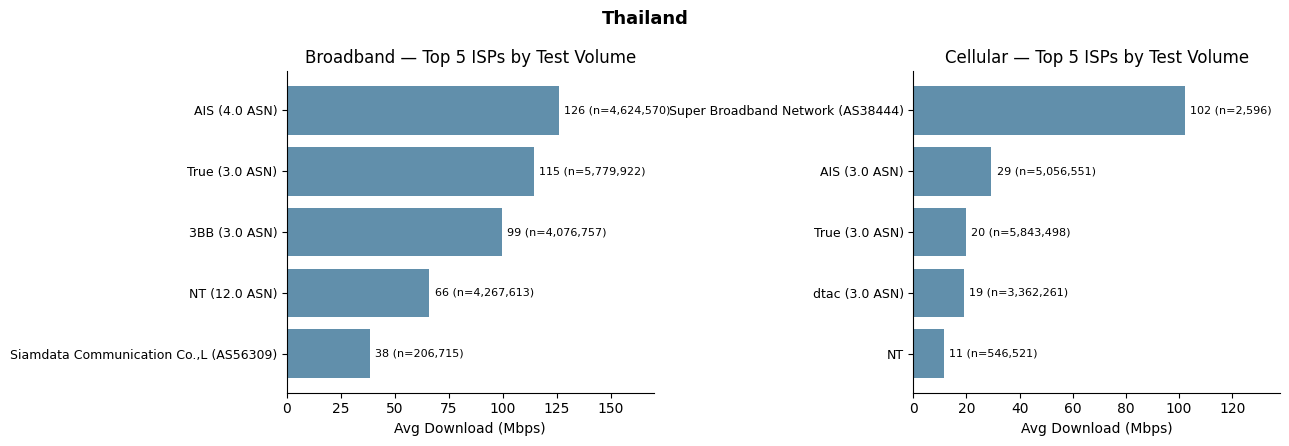

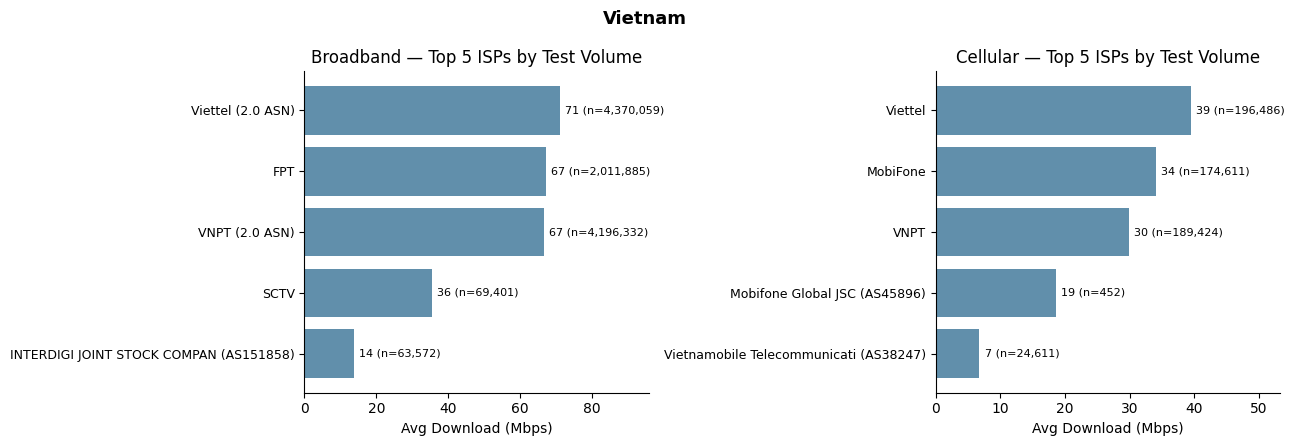

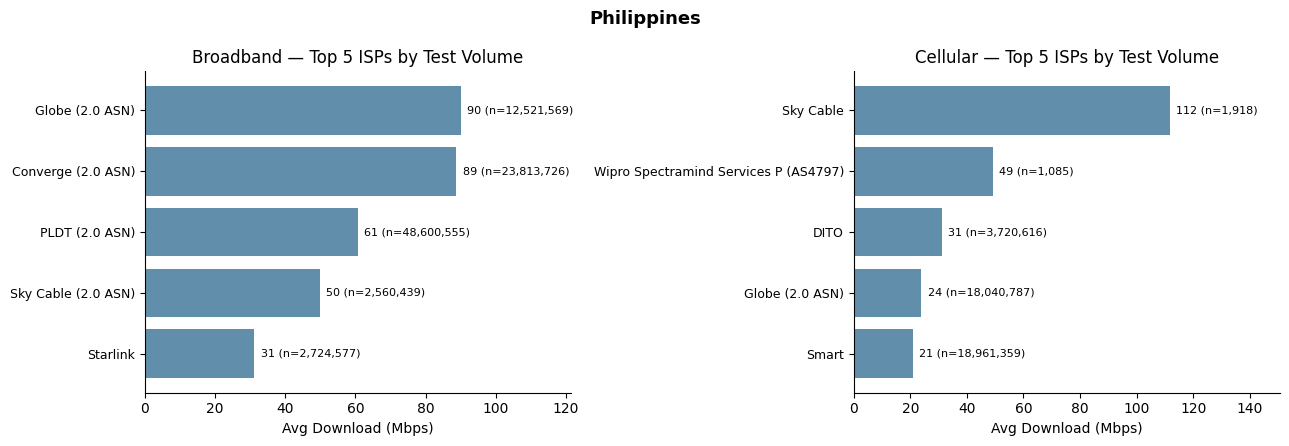

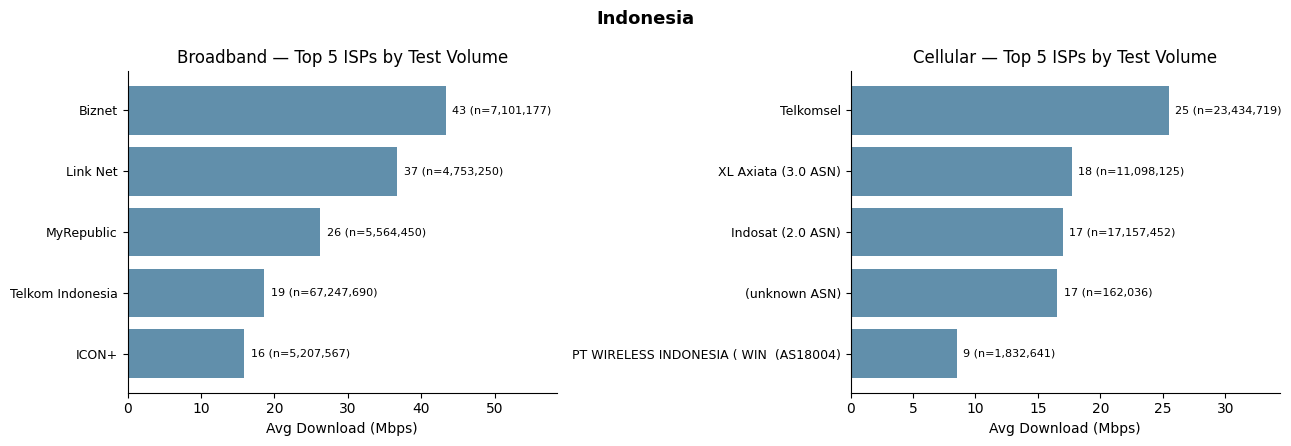

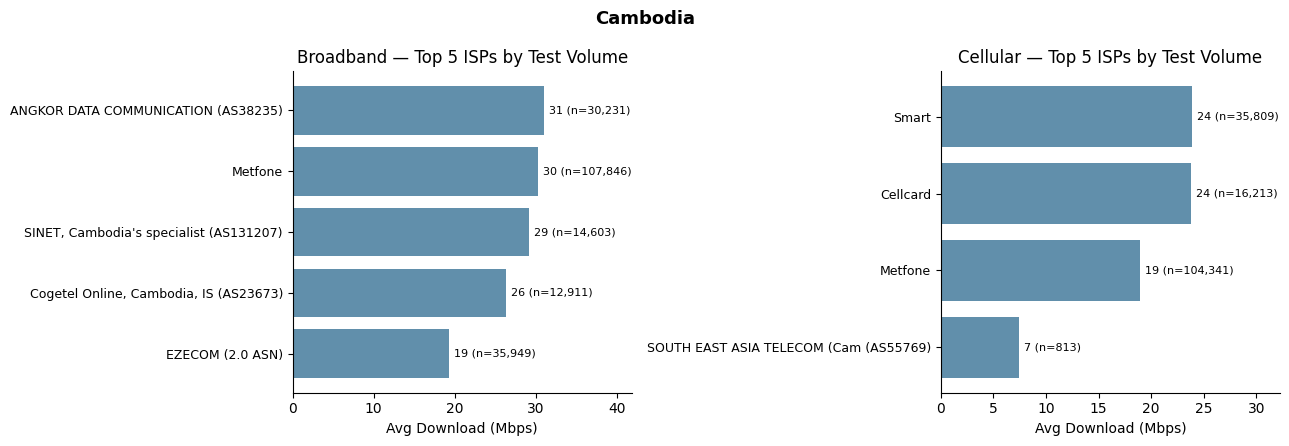

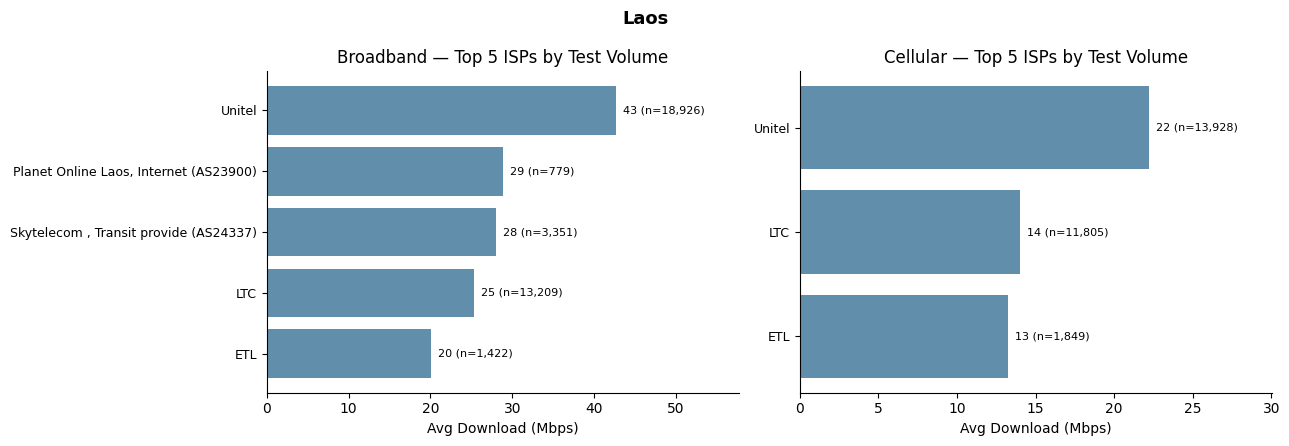

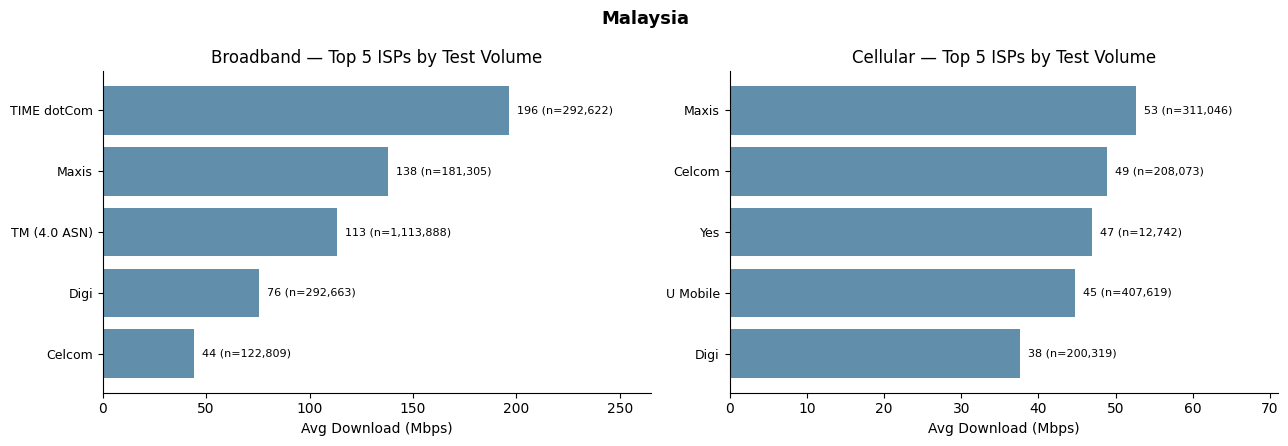

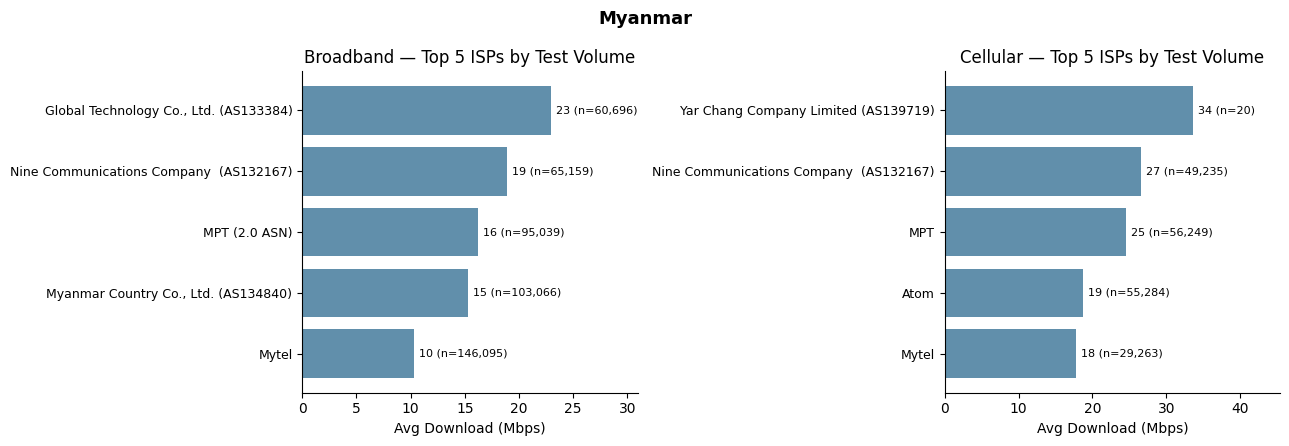

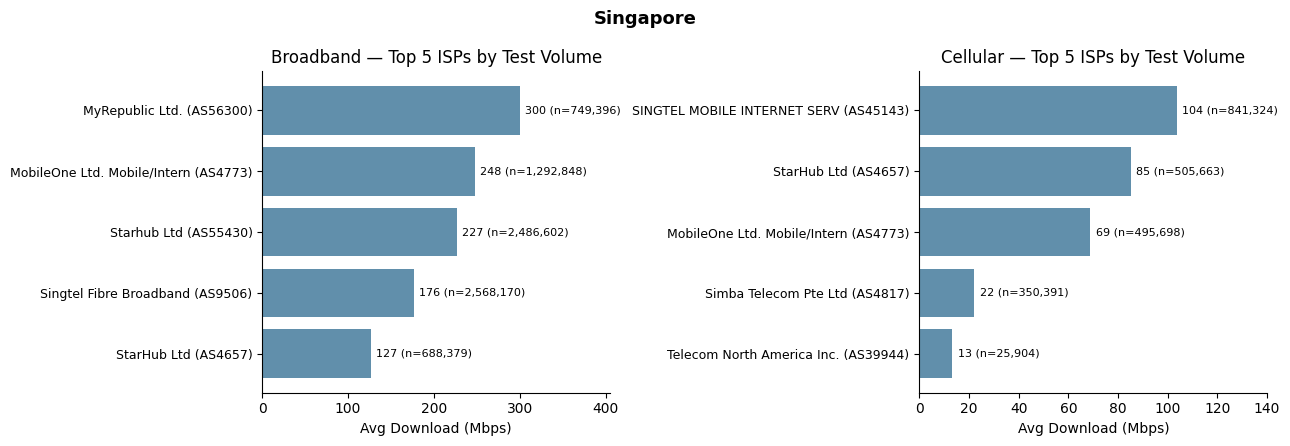

In [3]:
def top5_chart(country):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, nt, ttl in zip(axes, ['broadband', 'cellular'], ['Broadband', 'Cellular']):
        d = (brand_all[(brand_all['country'] == country) & (brand_all['network_type'] == nt)]
             .nlargest(5, 'total_tests')
             .sort_values('avg_d_mbps'))
        y = np.arange(len(d))
        ax.barh(y, d['avg_d_mbps'], color='#457b9d', alpha=0.85)
        for yi, (_, r) in zip(y, d.iterrows()):
            ax.text(r['avg_d_mbps'] + max(d['avg_d_mbps']) * 0.02, yi,
                    f"{r['avg_d_mbps']:.0f} (n={r['total_tests']:,.0f})", va='center', fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels(d['label'], fontsize=9)
        ax.set_xlim(0, d['avg_d_mbps'].max() * 1.35 if len(d) else 1)
        ax.set_xlabel('Avg Download (Mbps)')
        ax.set_title(f'{ttl} — Top 5 ISPs by Test Volume')
        ax.spines[['top', 'right']].set_visible(False)
    fig.suptitle(f'{COUNTRY_LABEL[country]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT / f'rq4_top5_{country}.png', dpi=150, bbox_inches='tight')
    plt.show()

for country in COUNTRIES:
    top5_chart(country)

## Step 2 — Market Share / HHI per Country

Same brand merge as Step 1 (`operator`, plus the exact-`as_name`-inherit rule). Share is
% of pooled test volume (2023-Q1 to 2025-Q4) within that country × network_type — same
`total_tests` basis as the source export's own `market_share_pct`. **HHI is computed over every
brand in that country × network_type (including unlabeled/unknown, however small)**, not just the
top 8 shown in the chart — the chart truncates for readability, the HHI number does not.

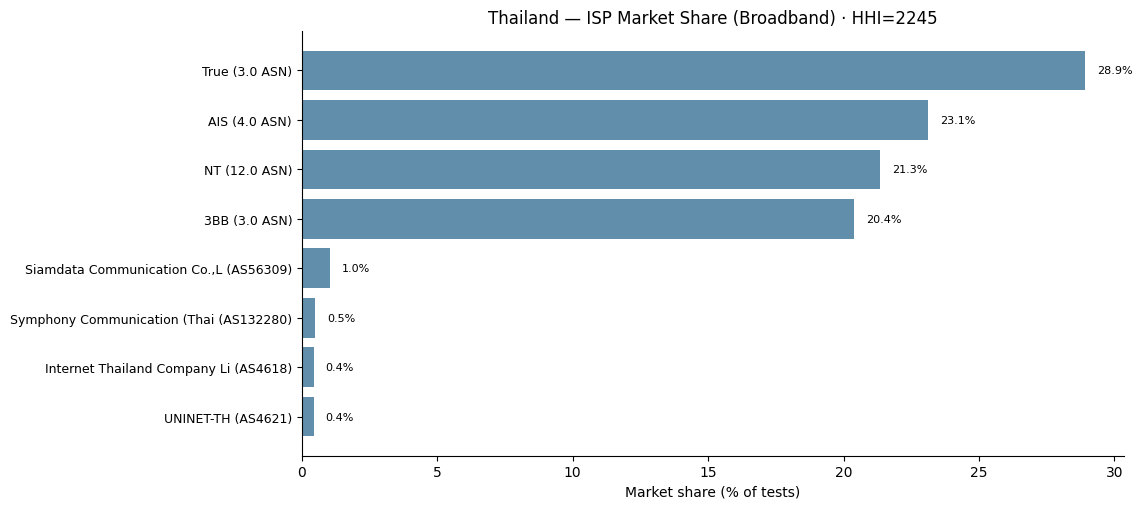

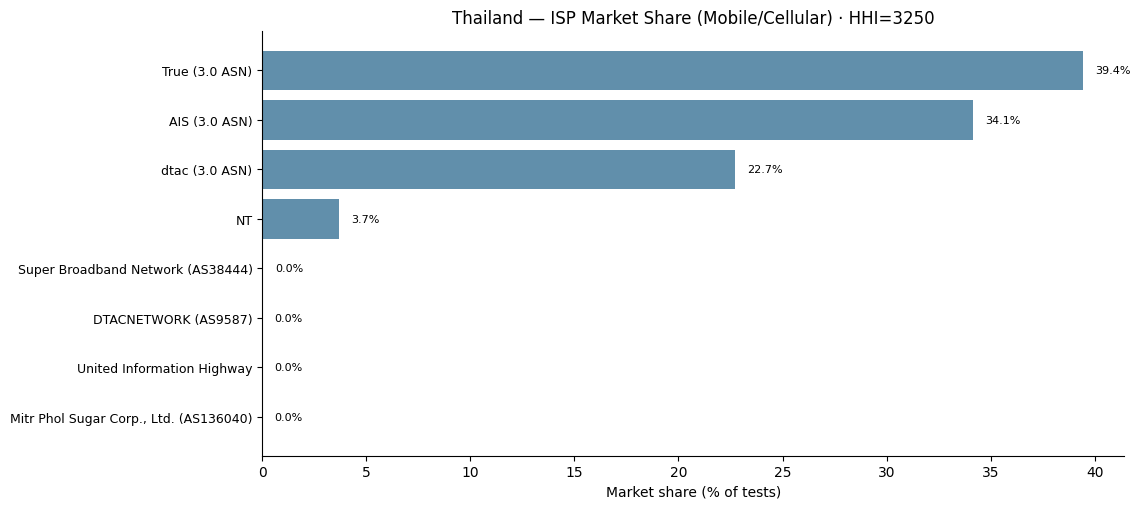

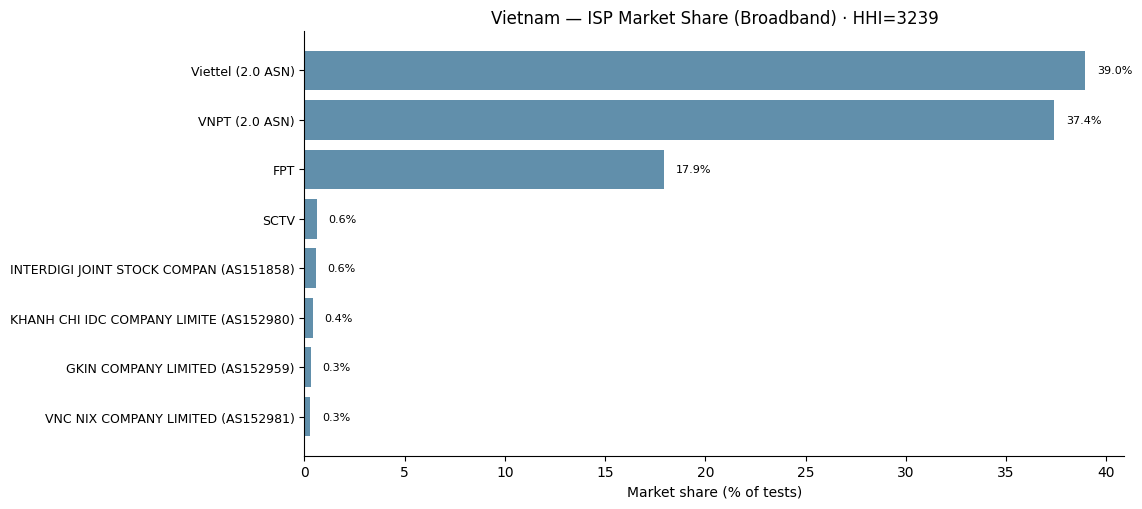

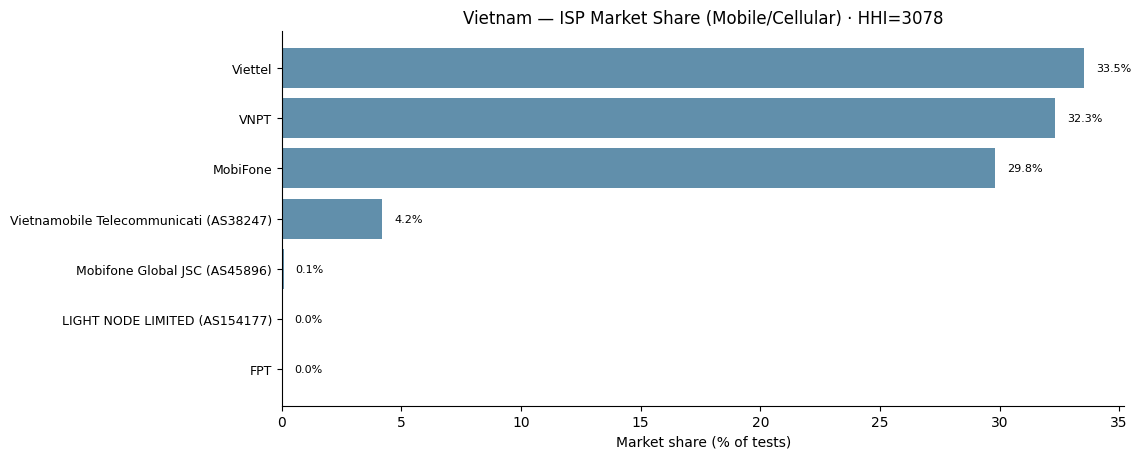

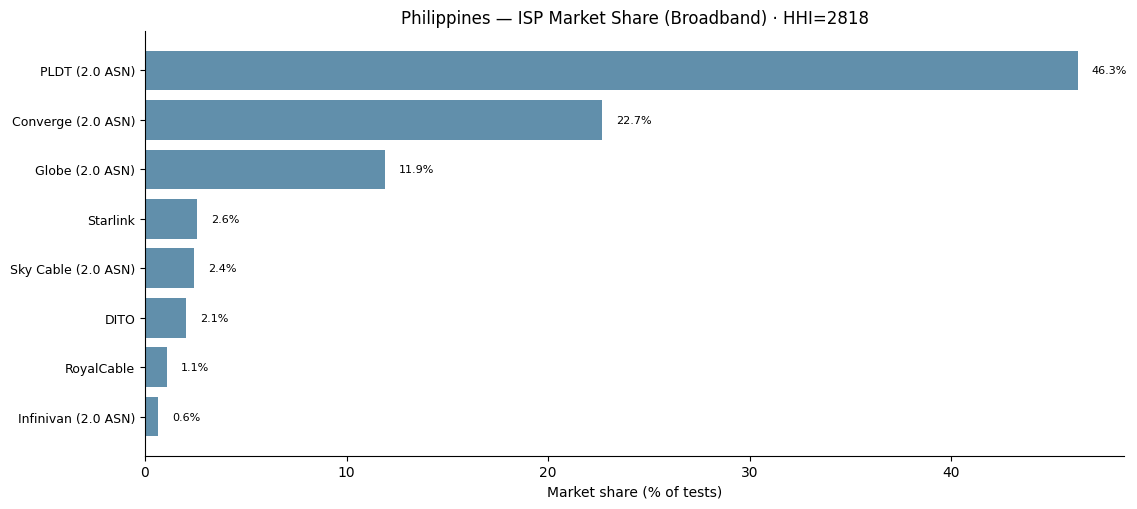

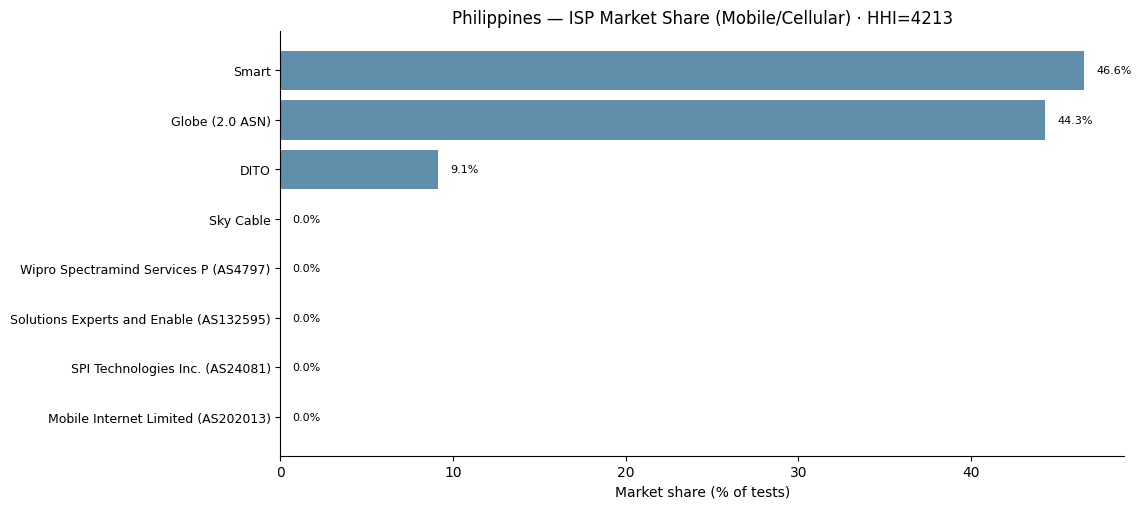

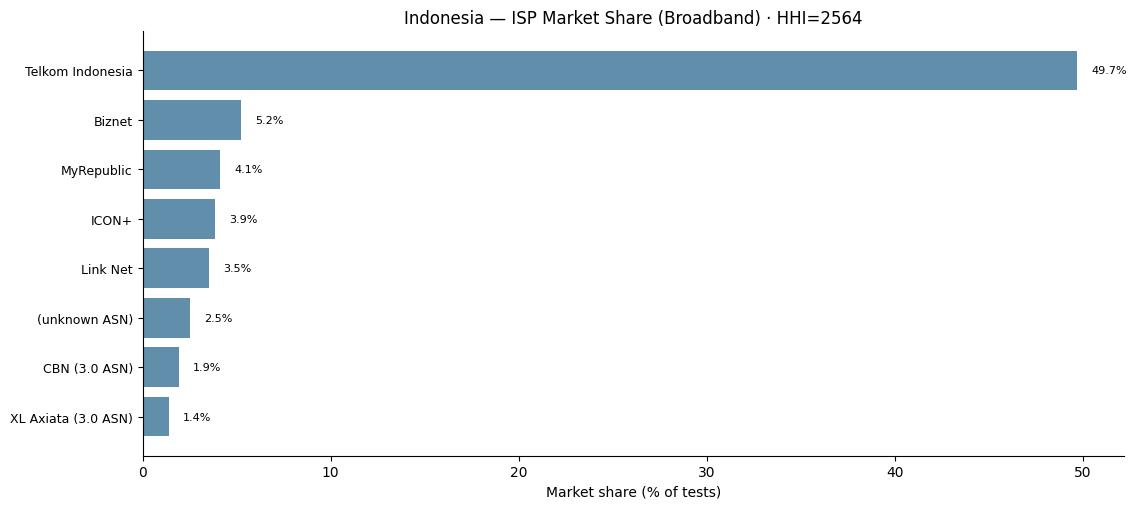

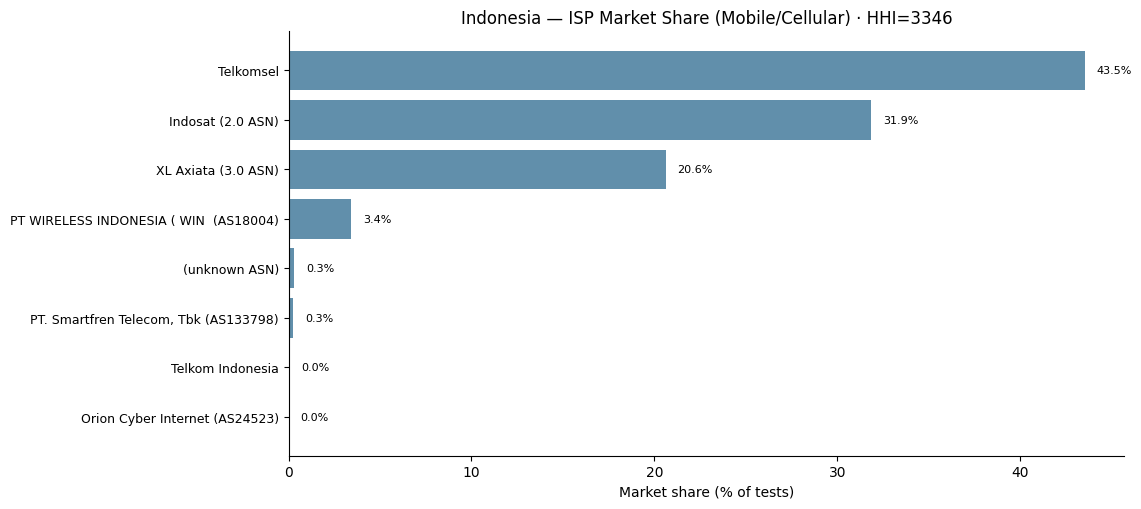

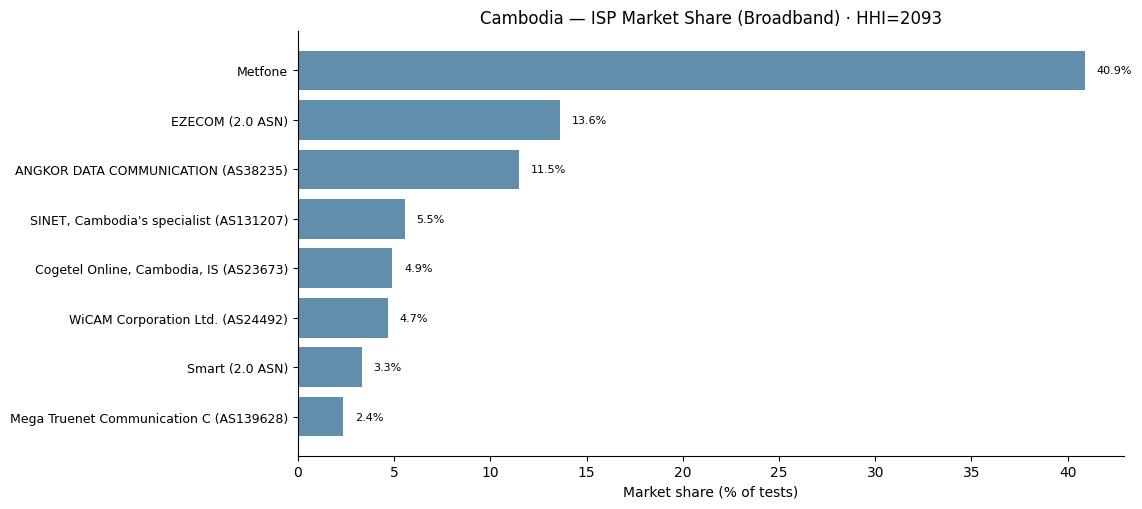

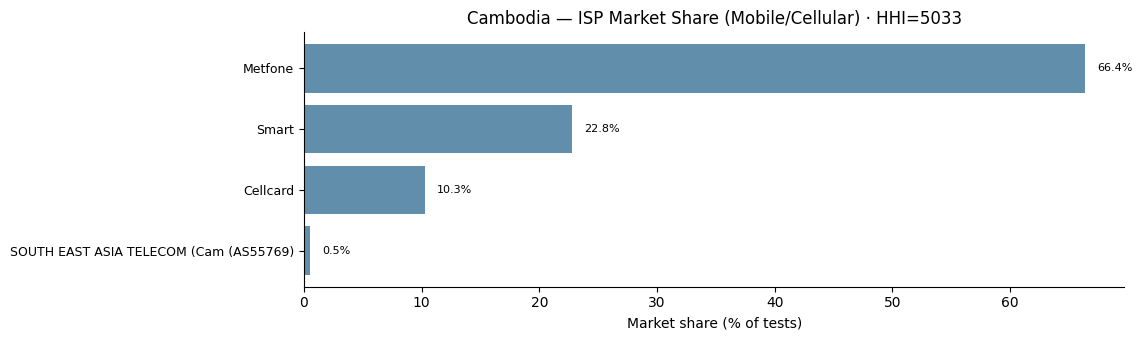

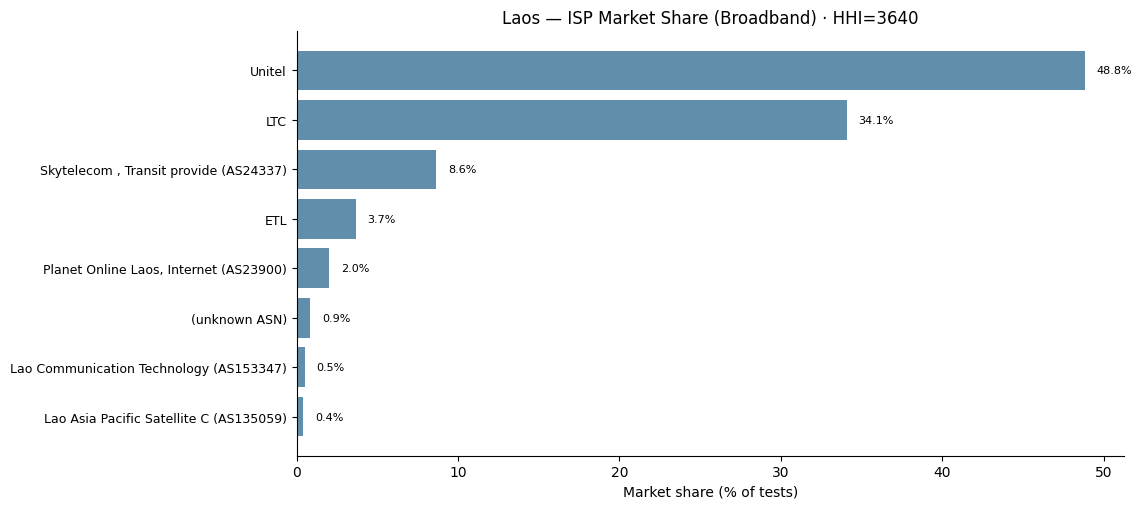

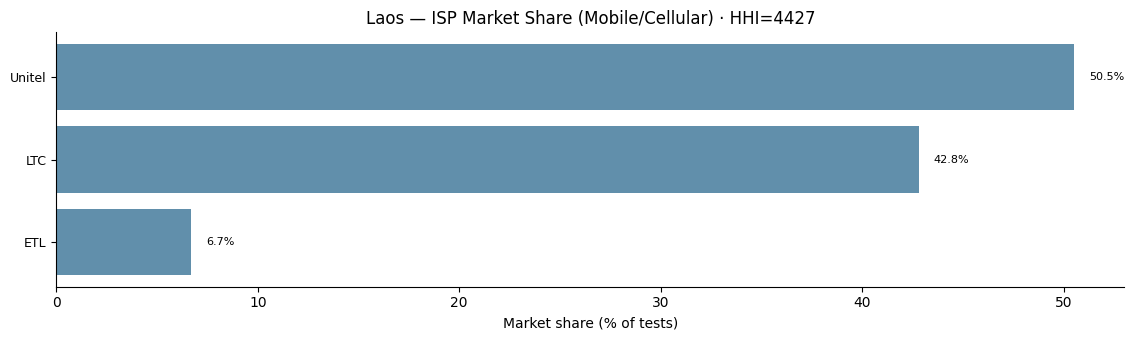

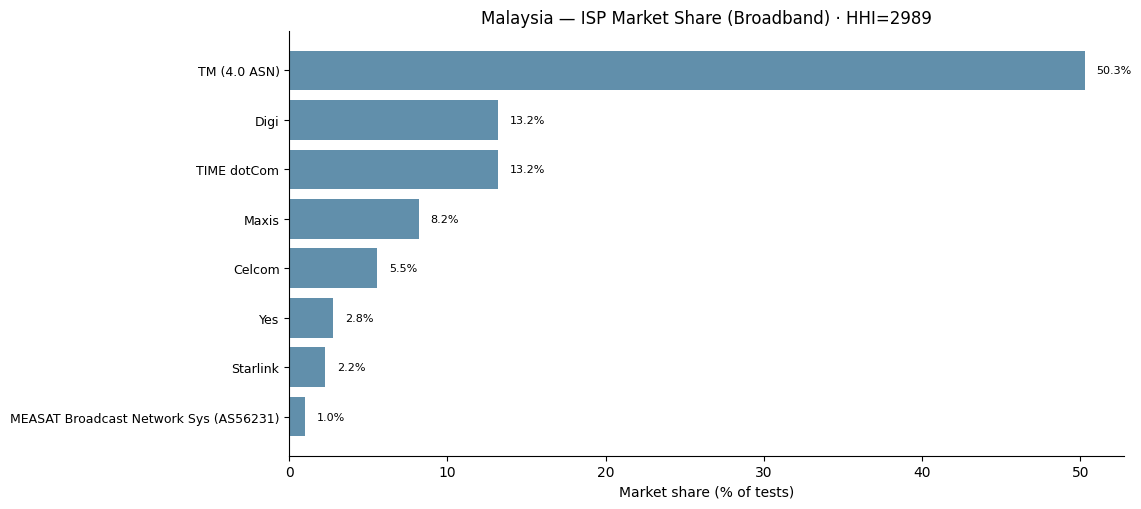

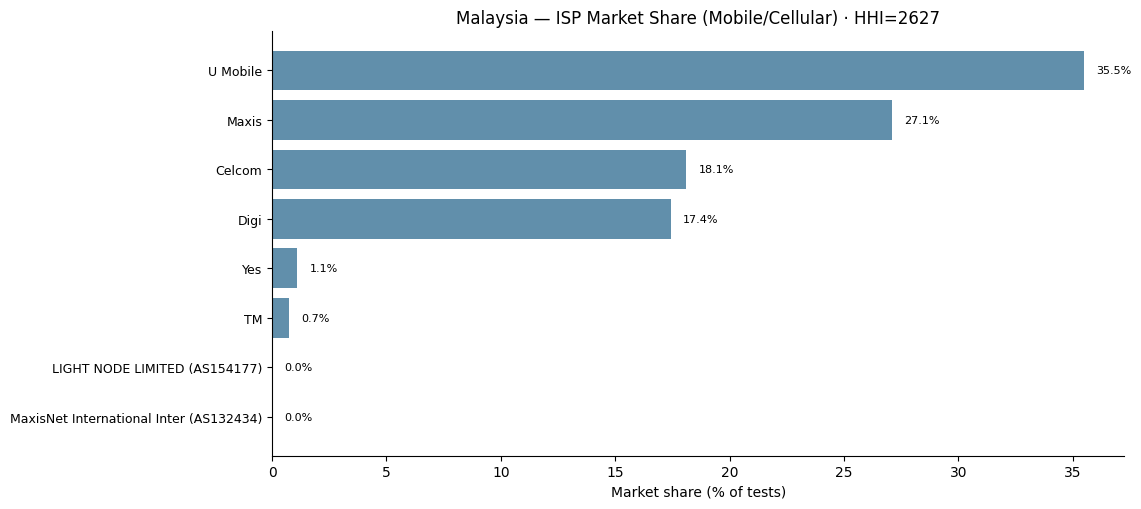

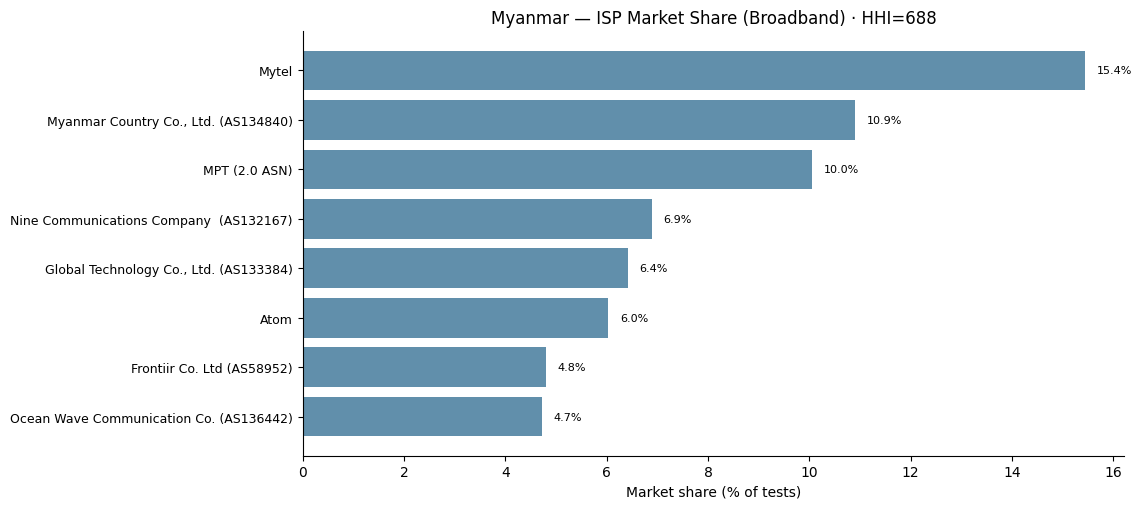

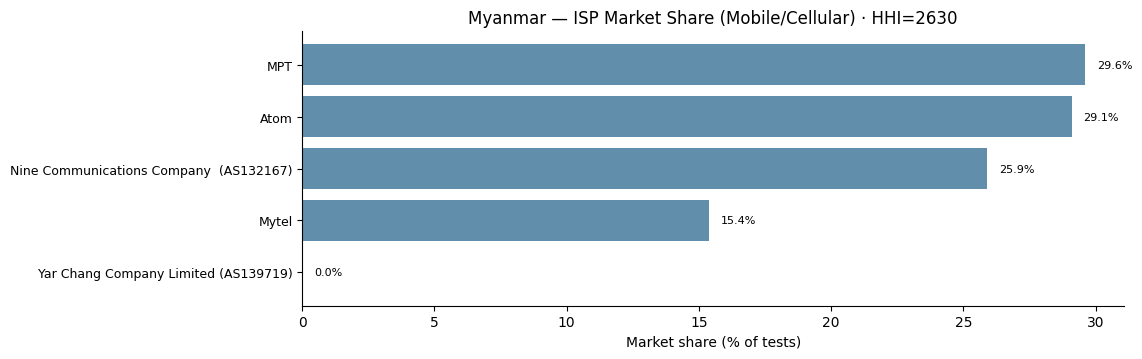

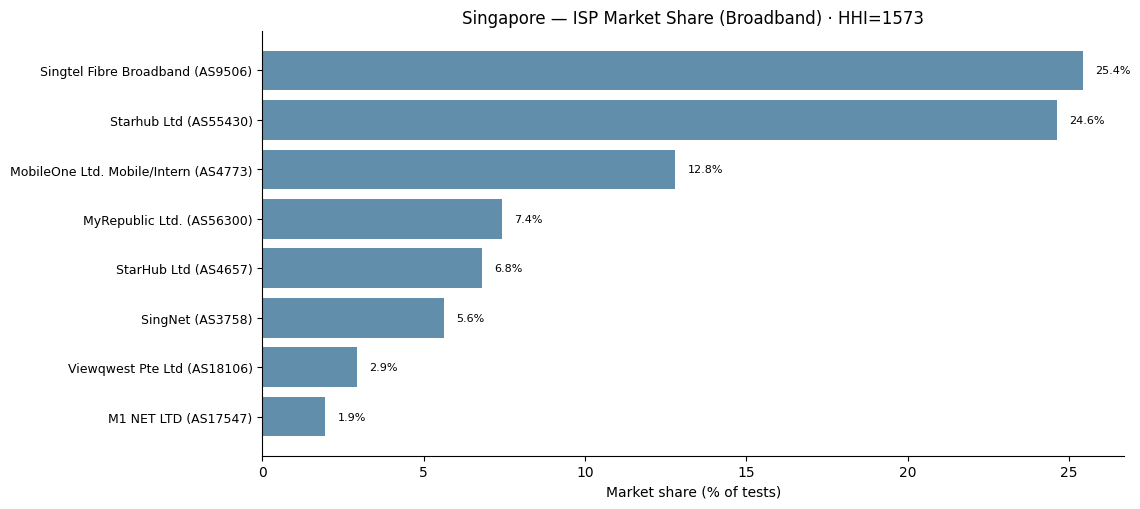

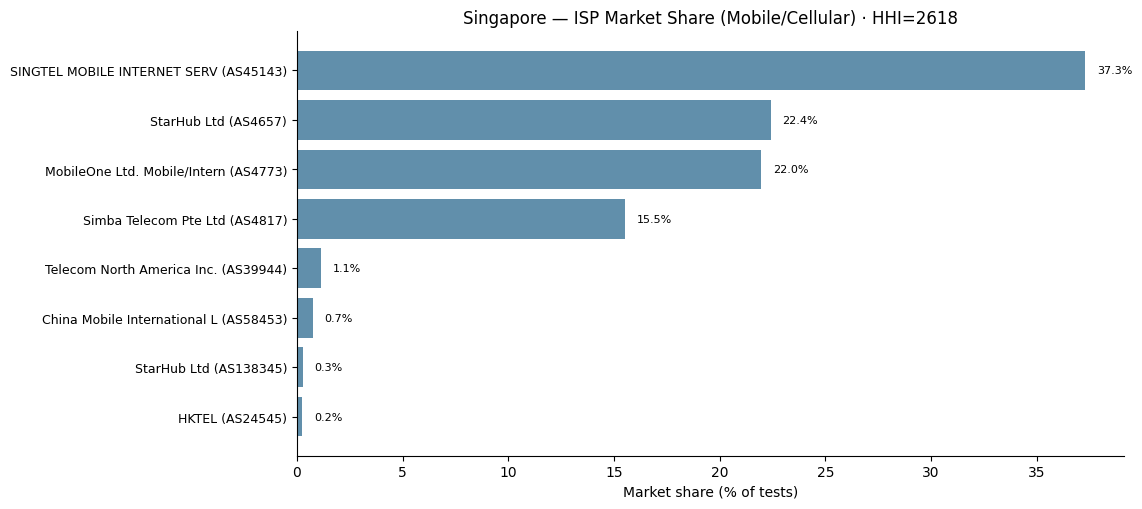

In [4]:
SEG_LABEL = {'broadband': 'Broadband', 'cellular': 'Mobile/Cellular'}
TOPN = 8

def market_share_chart(country):
    for nt in ['broadband', 'cellular']:
        d = brand_all[(brand_all['country'] == country) & (brand_all['network_type'] == nt)].copy()
        if d.empty:
            continue
        d['share_pct'] = 100 * d['total_tests'] / d['total_tests'].sum()
        hhi = float((d['share_pct'] ** 2).sum())

        top = d.nlargest(TOPN, 'share_pct').sort_values('share_pct')
        y = np.arange(len(top))

        fig, ax = plt.subplots(figsize=(11.5, max(3.5, 0.5 * len(top) + 1.2)))
        ax.barh(y, top['share_pct'], color='#457b9d', alpha=0.85)
        for yi, (_, r) in zip(y, top.iterrows()):
            ax.text(r['share_pct'] + top['share_pct'].max() * 0.015, yi, f"{r['share_pct']:.1f}%",
                    va='center', fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels(top['label'], fontsize=9)
        ax.set_xlabel('Market share (% of tests)')
        ax.set_title(f"{COUNTRY_LABEL[country]} — ISP Market Share ({SEG_LABEL[nt]}) \u00b7 HHI={hhi:.0f}")
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(OUT / f'rq4_marketshare_{country}_{nt}.png', dpi=150, bbox_inches='tight')
        plt.show()

for country in COUNTRIES:
    market_share_chart(country)

## Step 3 — Within-Country Gap: Best vs Worst Major ISP

**"Major"** = a brand holding **≥5% of pooled test volume** (2023-Q1 to 2025-Q4) in that
country × network_type — same brand merge, same share basis as Step 2. Checked first: no
non-consumer network (Starlink, Cogent, MEASAT) crosses 5% share anywhere in this data (Cogent
in Myanmar broadband is the closest, at 3.3%), so this cutoff alone keeps them out without needing
a separate role classification.

Countries/segments with fewer than 2 majors are dropped (no gap to compute).

In [5]:
brand_all['share_pct'] = (
    100 * brand_all['total_tests']
    / brand_all.groupby(['country', 'network_type'])['total_tests'].transform('sum')
)

majors = brand_all[brand_all['share_pct'] >= 5.0].copy()
n_majors = majors.groupby(['country', 'network_type']).size().rename('n_majors').reset_index()
print(n_majors.sort_values('n_majors').to_string(index=False))

gapable = majors.groupby(['country', 'network_type']).filter(lambda g: len(g) >= 2)

def gap_row(g):
    g = g.sort_values('avg_d_mbps')
    worst, best = g.iloc[0], g.iloc[-1]
    return pd.Series({
        'worst_brand': worst['label'], 'best_brand': best['label'],
        'worst_d': worst['avg_d_mbps'], 'best_d': best['avg_d_mbps'],
        'gap_ratio': best['avg_d_mbps'] / worst['avg_d_mbps'],
        'n_majors': len(g),
    })

within_gap = (gapable.groupby(['country', 'network_type'])
                      .apply(gap_row, include_groups=False)
                      .reset_index())
within_gap.to_csv(EXPORTS / 'rq4_within_gap.csv', index=False)
within_gap.sort_values('gap_ratio', ascending=False)

    country network_type  n_majors
  indonesia    broadband         2
    vietnam     cellular         3
   cambodia     cellular         3
  indonesia     cellular         3
       laos    broadband         3
       laos     cellular         3
   thailand     cellular         3
    vietnam    broadband         3
philippines    broadband         3
philippines     cellular         3
   thailand    broadband         4
  singapore     cellular         4
   cambodia    broadband         4
    myanmar     cellular         4
   malaysia     cellular         4
   malaysia    broadband         5
  singapore    broadband         6
    myanmar    broadband         6


,country,network_type,worst_brand,best_brand,worst_d,best_d,gap_ratio,n_majors
13,singapore,cellular,Simba Telecom Pte Ltd (AS4817),SINGTEL MOBILE INTERNET SERV (AS45143),22.213695,103.827438,4.674028,4
6,malaysia,broadband,Celcom,TIME dotCom,44.120591,196.268142,4.448448,5
12,singapore,broadband,StarHub Ltd (AS4657),MyRepublic Ltd. (AS56300),126.575960,300.222529,2.371876,6
2,indonesia,broadband,Telkom Indonesia,Biznet,18.619238,43.328416,2.327078,2
8,myanmar,broadband,Mytel,"Global Technology Co., Ltd. (AS133384)",10.291875,22.909320,2.225962,6
14,thailand,broadband,NT (12.0 ASN),AIS (4.0 ASN),65.936826,125.862096,1.908829,4
4,laos,broadband,LTC,Unitel,25.283371,42.700135,1.688862,3
5,laos,cellular,ETL,Unitel,13.276643,22.243260,1.675368,3
0,cambodia,broadband,EZECOM (2.0 ASN),ANGKOR DATA COMMUNICATION (AS38235),19.355271,31.009669,1.602130,4
15,thailand,cellular,dtac (3.0 ASN),AIS (3.0 ASN),18.924115,29.367727,1.551868,3


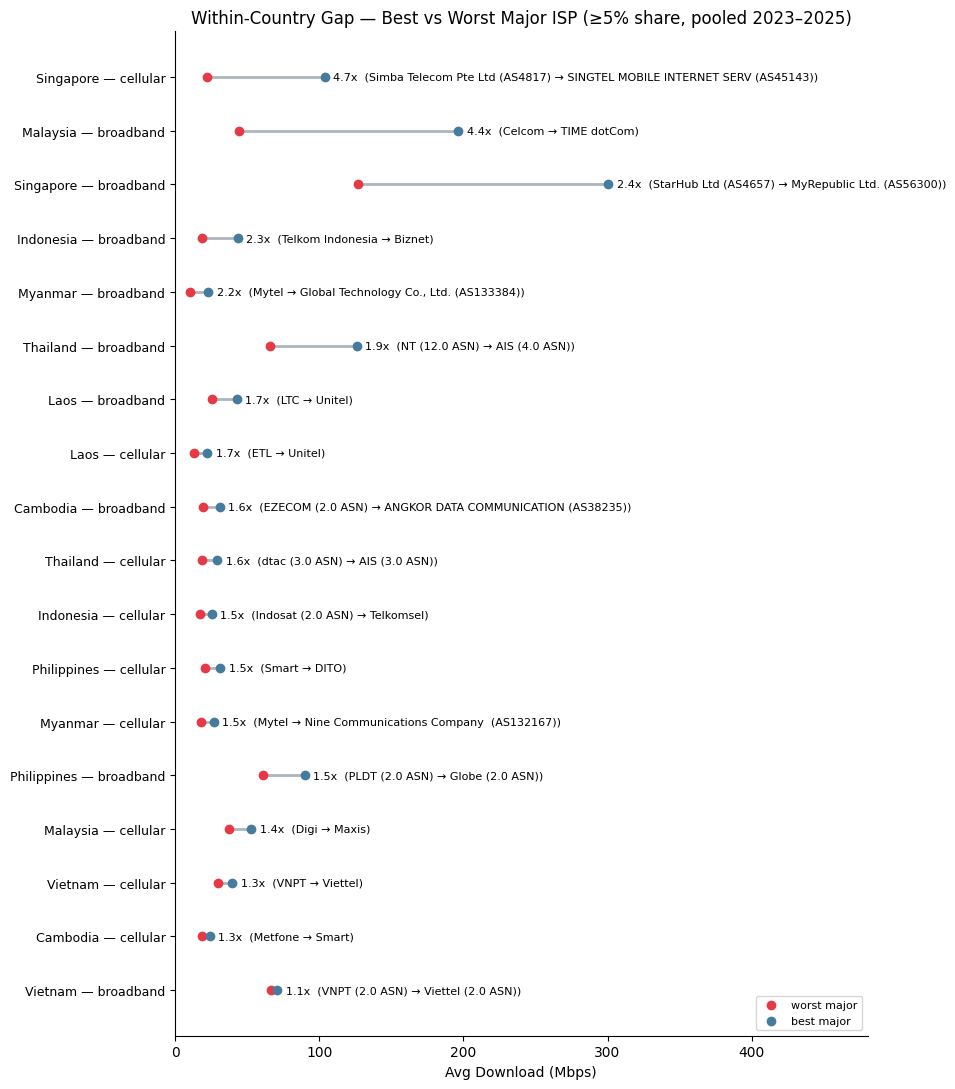

In [6]:
d = within_gap.copy()
d['label'] = d['country'].map(COUNTRY_LABEL) + ' — ' + d['network_type']
d = d.sort_values('gap_ratio')
y = np.arange(len(d))

fig, ax = plt.subplots(figsize=(9.5, 0.5 * len(d) + 2))
for yi, (_, r) in zip(y, d.iterrows()):
    ax.plot([r['worst_d'], r['best_d']], [yi, yi], color='#adb5bd', lw=2, zorder=1)
    ax.scatter(r['worst_d'], yi, color='#e63946', zorder=3, label='worst major' if yi == 0 else None)
    ax.scatter(r['best_d'], yi, color='#457b9d', zorder=3, label='best major' if yi == 0 else None)
    ax.text(max(r['worst_d'], r['best_d']) + d['best_d'].max() * 0.02, yi,
            f"{r['gap_ratio']:.1f}x  ({r['worst_brand']} \u2192 {r['best_brand']})",
            va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(d['label'], fontsize=9)
ax.set_xlim(0, d['best_d'].max() * 1.6)
ax.set_xlabel('Avg Download (Mbps)')
ax.set_title('Within-Country Gap — Best vs Worst Major ISP (\u22655% share, pooled 2023\u20132025)')
ax.legend(fontsize=8, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / 'rq4_within_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Cross-Country Leader Speed Comparison

For each country × network_type, the brand with the **most test volume** (pooled 2023-2025,
same brand merge as before) is that country's "leader" — the ISP most people there actually use.
Simple bar chart, one panel per network_type, one bar per country, sorted by speed.

In [7]:
leader_idx = brand_all.groupby(['country', 'network_type'])['total_tests'].idxmax()
leaders = brand_all.loc[leader_idx].reset_index(drop=True)
leaders.to_csv(EXPORTS / 'rq4_leaders.csv', index=False)
leaders[['country', 'network_type', 'brand', 'total_tests', 'avg_d_mbps']].sort_values(['network_type', 'avg_d_mbps'])

,country,network_type,brand,total_tests,avg_d_mbps
8,myanmar,broadband,Mytel,146095.0,10.291875
2,indonesia,broadband,Telkom Indonesia,67247690.0,18.619238
0,cambodia,broadband,Metfone,107846.0,30.257818
4,laos,broadband,Unitel,18926.0,42.700135
10,philippines,broadband,PLDT,48600555.0,60.638654
16,vietnam,broadband,Viettel,4370059.0,70.976073
6,malaysia,broadband,TM,1113888.0,113.057289
14,thailand,broadband,True,5779922.0,114.506019
12,singapore,broadband,Singtel Fibre Broadband (AS9506),2568170.0,176.333662
1,cambodia,cellular,Metfone,104341.0,18.969181


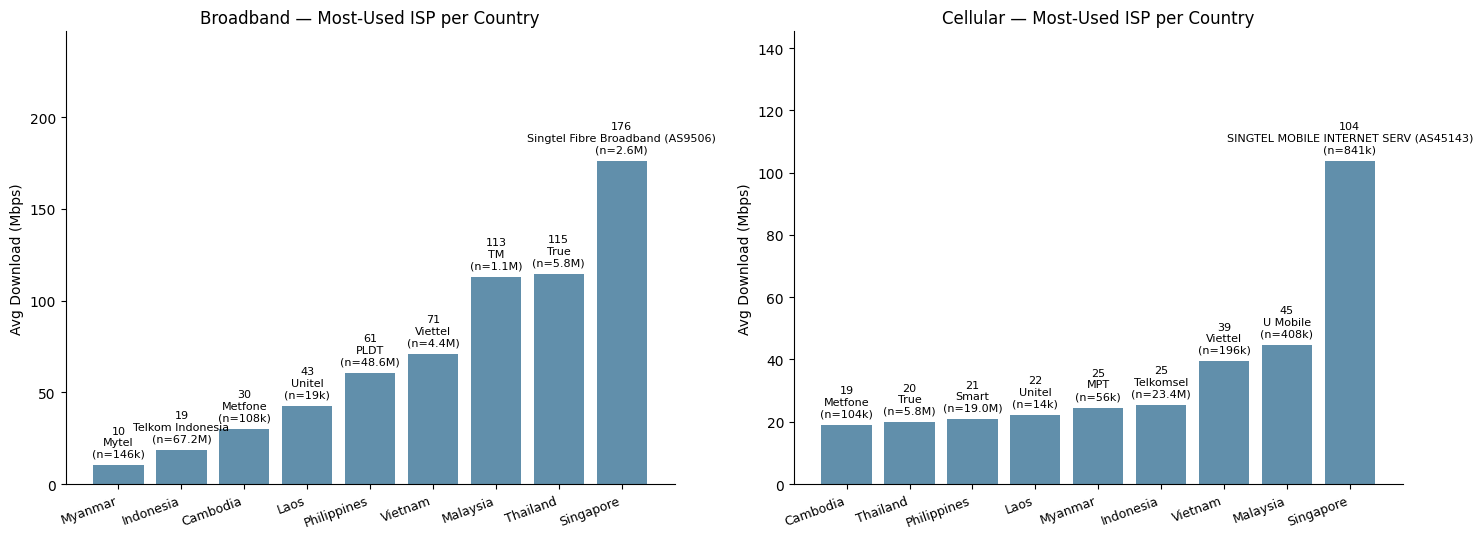

In [8]:
def fmt_n(n):
    if n >= 1_000_000:
        return f"{n / 1_000_000:.1f}M"
    if n >= 1_000:
        return f"{n / 1_000:.0f}k"
    return f"{n:,.0f}"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, nt, ttl in zip(axes, ['broadband', 'cellular'], ['Broadband', 'Cellular']):
    d = leaders[leaders['network_type'] == nt].sort_values('avg_d_mbps')
    x = np.arange(len(d))
    ax.bar(x, d['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for xi, (_, r) in zip(x, d.iterrows()):
        ax.text(xi, r['avg_d_mbps'] + d['avg_d_mbps'].max() * 0.02,
                f"{r['avg_d_mbps']:.0f}\n{r['brand']}\n(n={fmt_n(r['total_tests'])})",
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([COUNTRY_LABEL[c] for c in d['country']], fontsize=9, rotation=20, ha='right')
    ax.set_ylim(0, d['avg_d_mbps'].max() * 1.4)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(f'{ttl} — Most-Used ISP per Country')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / 'rq4_leader_speed_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Fastest Major ISP, Cross-Country Comparison

Not "most used" this time — **fastest**, restricted to majors (≥5% share, same cutoff as Step 3)
so a tiny niche ASN with a lucky small sample doesn't win by accident. One bar per country, per
network_type.

In [9]:
fastest_idx = majors.groupby(['country', 'network_type'])['avg_d_mbps'].idxmax()
fastest = majors.loc[fastest_idx].reset_index(drop=True)
fastest.to_csv(EXPORTS / 'rq4_fastest_major.csv', index=False)
fastest[['country', 'network_type', 'brand', 'avg_d_mbps', 'share_pct', 'total_tests']].sort_values(['network_type', 'avg_d_mbps'])

,country,network_type,brand,avg_d_mbps,share_pct,total_tests
8,myanmar,broadband,"Global Technology Co., Ltd. (AS133384)",22.909320,6.415979,60696.0
0,cambodia,broadband,ANGKOR DATA COMMUNICATION (AS38235),31.009669,11.463207,30231.0
4,laos,broadband,Unitel,42.700135,48.832469,18926.0
2,indonesia,broadband,Biznet,43.328416,5.249971,7101177.0
16,vietnam,broadband,Viettel,70.976073,38.951703,4370059.0
10,philippines,broadband,Globe,90.000612,11.920818,12521569.0
14,thailand,broadband,AIS,125.862096,23.132701,4624570.0
6,malaysia,broadband,TIME dotCom,196.268142,13.208648,292622.0
12,singapore,broadband,MyRepublic Ltd. (AS56300),300.222529,7.421273,749396.0
5,laos,cellular,Unitel,22.243260,50.496701,13928.0


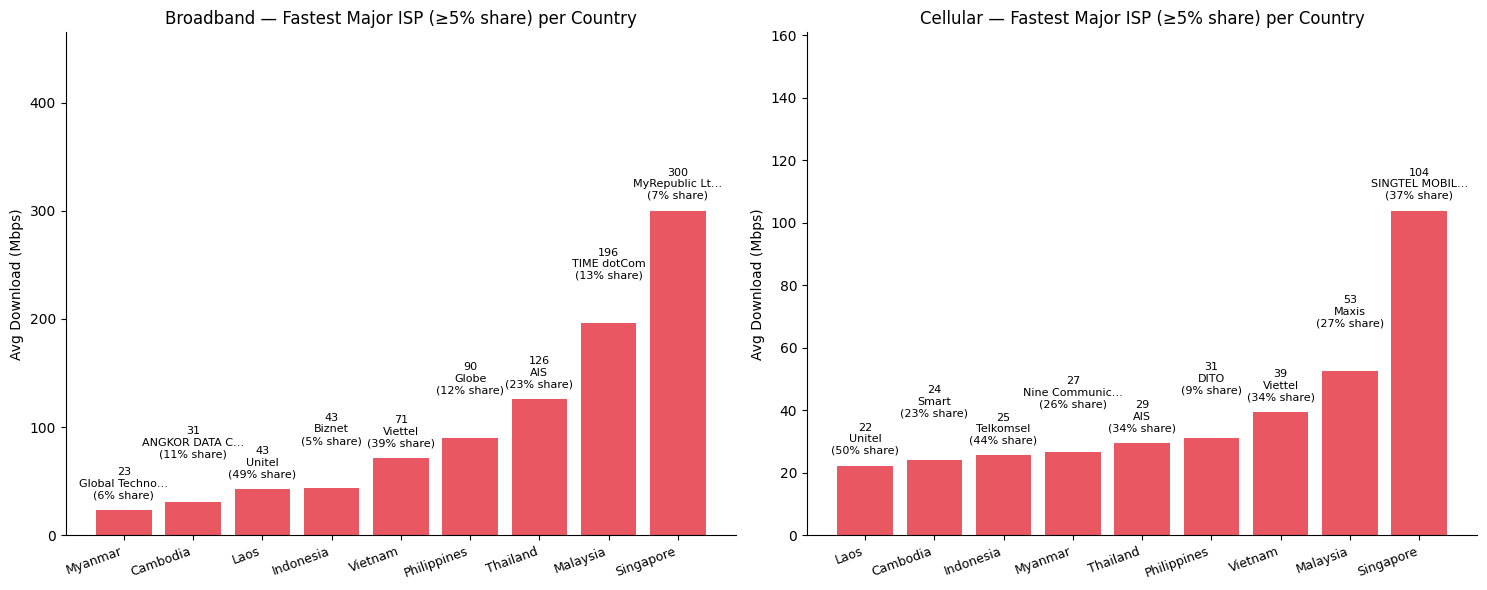

In [10]:
def short_label(brand, width=14):
    name = brand.split(' (AS')[0]  # drop the (ASxxxxx) suffix for chart display only
    return name if len(name) <= width else name[:width - 1] + '\u2026'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, nt, ttl in zip(axes, ['broadband', 'cellular'], ['Broadband', 'Cellular']):
    d = fastest[fastest['network_type'] == nt].sort_values('avg_d_mbps')
    x = np.arange(len(d))
    ax.bar(x, d['avg_d_mbps'], color='#e63946', alpha=0.85)
    for xi, (_, r) in zip(x, d.iterrows()):
        # stagger label height on alternating bars so adjacent short bars don't collide
        stagger = 0.10 if xi % 2 else 0.0
        ax.text(xi, r['avg_d_mbps'] + d['avg_d_mbps'].max() * (0.03 + stagger),
                f"{r['avg_d_mbps']:.0f}\n{short_label(r['brand'])}\n({r['share_pct']:.0f}% share)",
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([COUNTRY_LABEL[c] for c in d['country']], fontsize=9, rotation=20, ha='right')
    ax.set_ylim(0, d['avg_d_mbps'].max() * 1.55)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(f'{ttl} — Fastest Major ISP (\u22655% share) per Country')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / 'rq4_fastest_major_compare.png', dpi=150, bbox_inches='tight')
plt.show()